In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) + "/src")

from visualizer import plot_ring_state
from ring_attractor import RingAttractor, CosineKernelInitStrategy
from nonlinearity import ReLUNonlinearity
from ring_attractor import RingAttractorSimulator

<PolarAxes: >

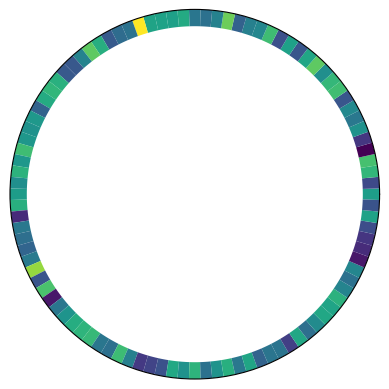

In [2]:
rng = np.random.default_rng(42)
ring_size = 100

attractor = RingAttractor(
    ring_size,
    CosineKernelInitStrategy(j0=-2.0, j1=4.0),
    ReLUNonlinearity(),
    rng   
)

plot_ring_state(attractor)

<PolarAxes: >

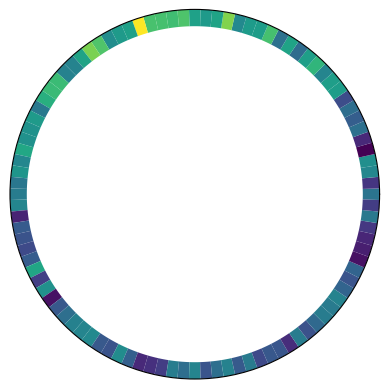

In [3]:
def create_cue_input(attractor: RingAttractor, theta_target: float, amplitude: float = 1) -> np.ndarray:
    return amplitude * np.cos(attractor.neuron_angles - theta_target)

# Notes:
# - larger tau = slower dynamics
simulator = RingAttractorSimulator(attractor, 0.01, tau=100, sigma=0.1, rng=rng) # Some random parameters

for i in range(100):
    cue_input = create_cue_input(attractor, np.pi / 2)
    simulator.perform_single_step(cue_input)

plot_ring_state(attractor)

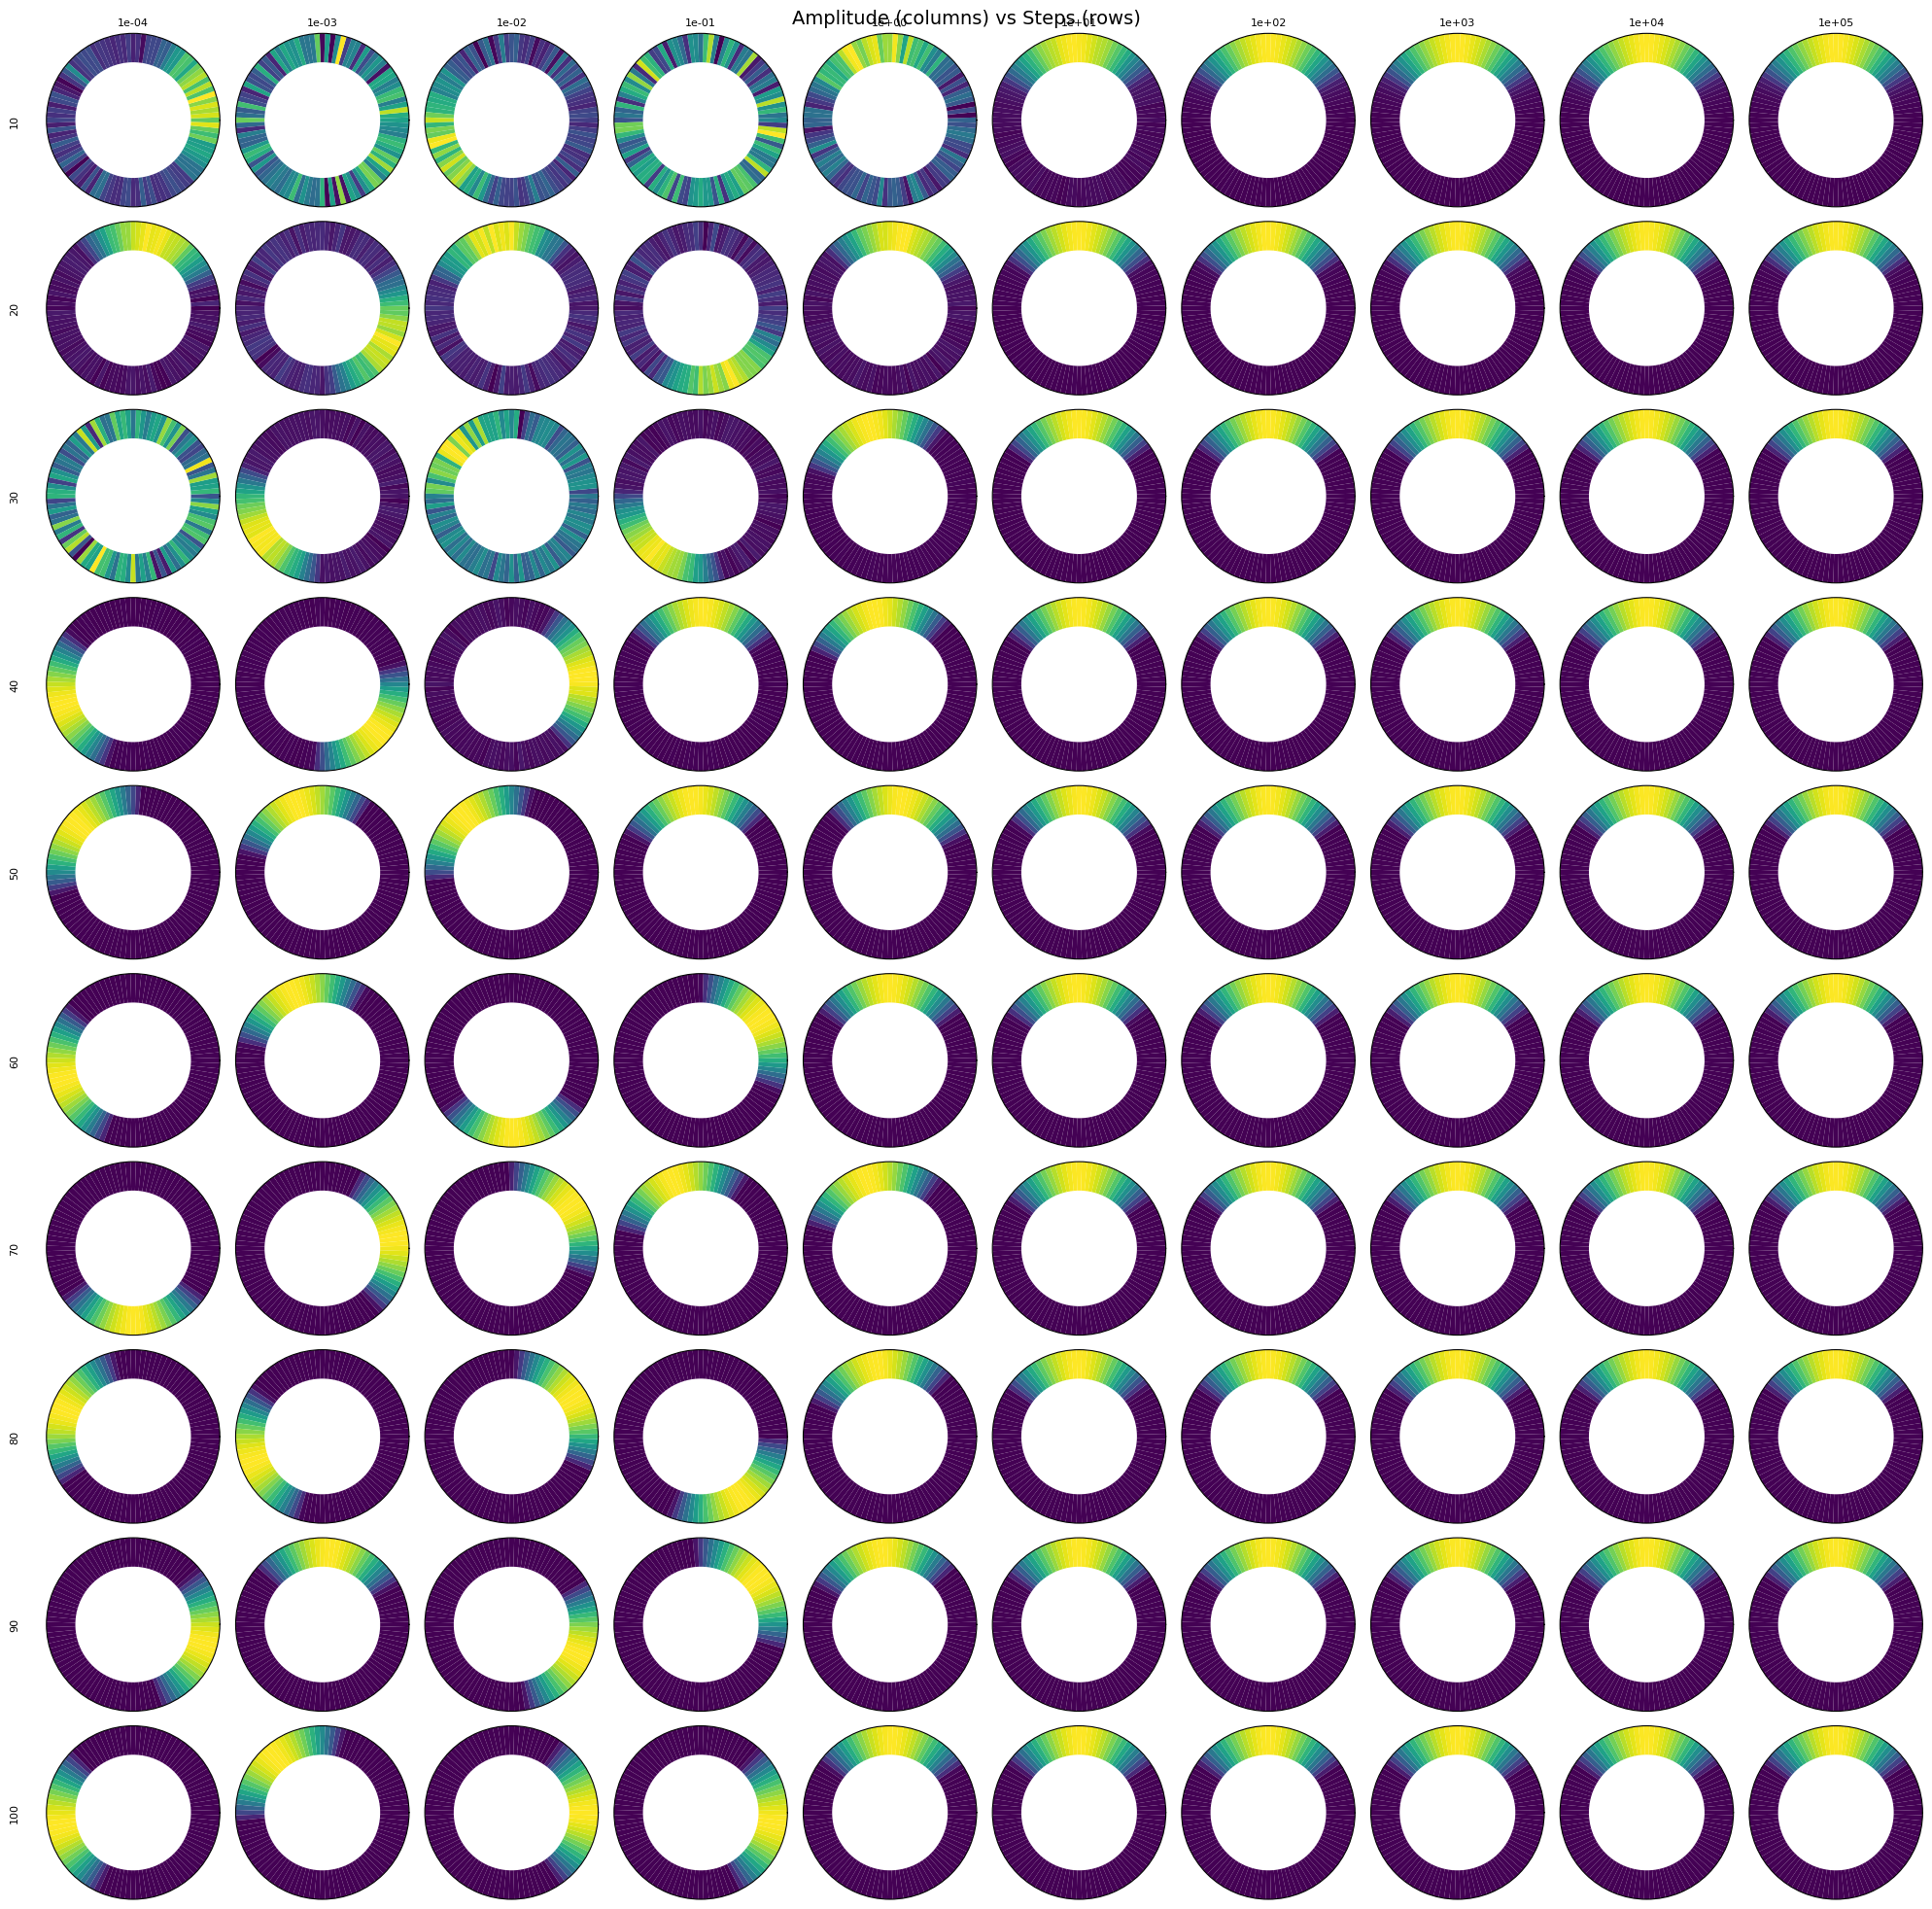

In [6]:
# Parameter ranges
amplitudes = np.logspace(-4, 5, 10)  # 10^-4 to 10^5, 10 values
n_steps_range = np.arange(10, 110, 10)  # 10, 20, ..., 100
# Create figure with polar subplots
fig, axes = plt.subplots(
    10, 10, 
    figsize=(20, 20),
    subplot_kw={"projection": "polar"}
)
for row, n_steps in enumerate(n_steps_range):
    for col, amplitude in enumerate(amplitudes):
        # Fresh attractor for each run
        rng = np.random.default_rng()  # same seed for fair comparison
        init_strategy = CosineKernelInitStrategy(j0=-2.0, j1=4.0)
        nonlinearity = ReLUNonlinearity()  # adjust to your class
        attractor = RingAttractor(100, init_strategy, nonlinearity, rng)
        simulator = RingAttractorSimulator(attractor, dt=0.5, tau=100, sigma=0.1, rng=rng)
        
        # Run simulation
        for _ in range(n_steps):
            cue_input = create_cue_input(attractor, np.pi / 2, amplitude)
            simulator.perform_single_step(cue_input)
        
        # Plot
        ax = axes[row, col]
        plot_ring_state(attractor, ax=ax, bottom=2)
# Add labels
for col, amp in enumerate(amplitudes):
    axes[0, col].set_title(f"{amp:.0e}", fontsize=8)
for row, n_steps in enumerate(n_steps_range):
    axes[row, 0].set_ylabel(f"{n_steps}", fontsize=8, labelpad=20)
fig.suptitle("Amplitude (columns) vs Steps (rows)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Let's show the confidence metri (decode_theta second return value) decrease as we run more iterations of the network with the cue,
# and then decrease slightly after we stop providing input (diffusion of the bump?)